# Deterministic Execution: From Data to Code

This tutorial demonstrates the deterministic **Execution Engine** of `skforecast-ai` using a single-shot forecast.

While the LLM (Reasoning Engine) is great for exploring and diagnosing, the actual forecasting pipeline is 100% rule-based and transparent. We will profile a dataset, execute a forecast with probabilistic intervals, and then output the **exact, standalone Python script** that produced the results.

No black boxes. No hallucinated code.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from skforecast_ai import ForecastingAssistant

import warnings
# warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (10, 4)

## 1. Load Real-World Data

We'll use the `h2o_exog` dataset, which models monthly corticosteroid sales alongside two exogenous variables.

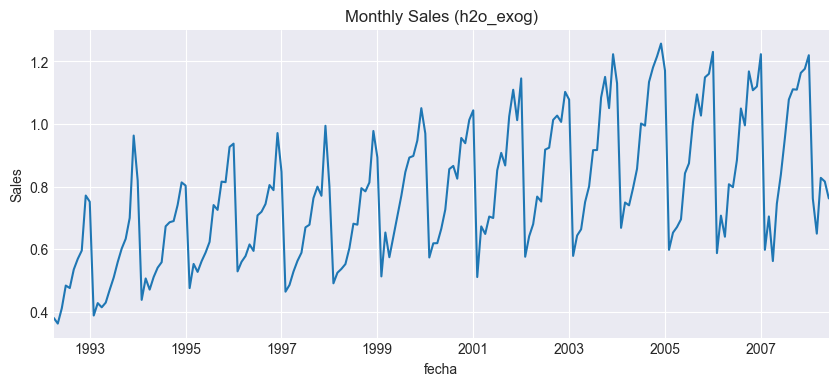

In [2]:
url = 'https://raw.githubusercontent.com/skforecast/skforecast-datasets/main/data/h2o_exog.csv'
data = pd.read_csv(url)

data['fecha'] = pd.to_datetime(data['fecha'])
data = data.set_index('fecha')
data = data.asfreq('MS')

ax = data['y'].plot(title='Monthly Sales (h2o_exog)')
ax.set_ylabel('Sales')
plt.show()

## 2. End-to-End Execution with Intervals

We initialize the assistant without an API key. In this default deterministic mode, the assistant runs entirely locally.

We will request an 80% prediction interval (`interval=[0.1, 0.9]`) to quantify our uncertainty over a 12-month horizon.

In [5]:
assistant = ForecastingAssistant()  # Deterministic mode

# Profile, plan, generate code, and execute in one call
result = assistant.forecast(
             data        = data,
             target      = 'y',
             date_column = 'fecha',
             steps       = 12,
             interval    = [0.1, 0.9]
         )

print("Forecast Metrics (Training set estimation):")
display(result.metrics)

print("\nPredictions (First 5 steps):")
display(result.predictions.head())

Forecast Metrics (Training set estimation):


,series,MAE,MSE,MASE,MAPE
0,y,0.053628,0.003652,0.574034,0.056964



Predictions (First 5 steps):


,pred
2005-04-01,0.710531
2005-05-01,0.730081
2005-06-01,0.784987
2005-07-01,0.918614
2005-08-01,0.968515


Let's visualize the historical data along with our point predictions and uncertainty intervals.

In [9]:
result.predictions

,pred,lower_bound,upper_bound
2005-04-01,0.710531,0.648570,0.757217
2005-05-01,0.730081,0.630438,0.797829
2005-06-01,0.784987,0.745791,0.850296
2005-07-01,0.918614,0.874048,0.976897
2005-08-01,0.968515,0.920662,1.055727
2005-09-01,1.125507,1.056967,1.189389
2005-10-01,1.148723,1.075741,1.212128
2005-11-01,1.205526,1.129893,1.267258
2005-12-01,1.239261,1.169350,1.308602
2006-01-01,1.142778,1.072375,1.211480


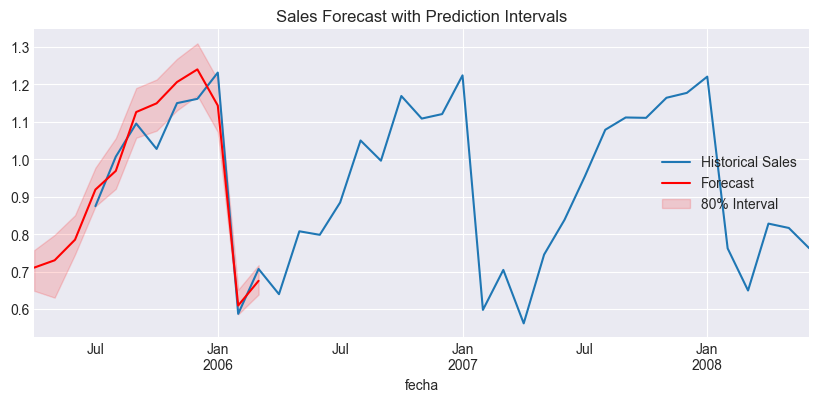

In [10]:
fig, ax = plt.subplots()

# Plot last 3 years of history
data['y'].iloc[-36:].plot(ax=ax, label='Historical Sales')

# Plot predictions
preds = result.predictions
preds['pred'].plot(ax=ax, label='Forecast', color='red')

# Fill intervals
ax.fill_between(
    preds.index,
    preds['lower_bound'],
    preds['upper_bound'],
    color='red',
    alpha=0.15,
    label='80% Interval'
)

ax.set_title('Sales Forecast with Prediction Intervals')
ax.legend()
plt.show()

## 3. The Fidelity Guarantee: `result.code`

The defining feature of the `skforecast-ai` Execution Engine is the **Fidelity Guarantee**.

The script stored in `result.code` is not an approximation. It is the literal Python string that was executed dynamically via `exec()` to produce the predictions and metrics you see above.

You can copy this code, save it to a `.py` file, and deploy it to production. It relies strictly on standard `skforecast` and `scikit-learn` libraries.

In [11]:
print(result.code)

import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from skforecast.metrics import mean_absolute_scaled_error
from sklearn.linear_model import Ridge
from skforecast.preprocessing import RollingFeatures, CalendarFeatures
from skforecast.recursive import ForecasterRecursive

# Load data
data = pd.read_csv('data.csv', index_col=0, parse_dates=True)

data = data.asfreq('MS')
data = data.sort_index()

# Train/test split
end_train = '2005-03-01'  # 80% of data, adjust to change the split point
data_train = data.loc[:end_train]
data_test  = data.loc[data.index > end_train]
exog_features = ['exog_1', 'exog_2']

print(
    f"Train dates : {data_train.index.min()} --- {data_train.index.max()}  (n={len(data_train)})"
)
print(
    f"Test dates  : {data_test.index.min()} --- {data_test.index.max()}  (n={len(data_test)})"
)

window_features = RollingFeatures(
    stats        = ['mean

## 4. Supporting All Forecaster Types

While the default behavior uses `ForecasterRecursive`, `skforecast-ai` supports every major forecasting strategy in the `skforecast` ecosystem. You can easily switch between them using the `forecaster` argument.

Below, we demonstrate generating predictions for the same dataset using different underlying methodologies.

### ForecasterDirect
Trains a separate model for each step in the forecast horizon. Better for long horizons or when patterns change over time.

In [12]:
result_direct = assistant.forecast(
                    data        = data,
                    target      = 'y',
                    date_column = 'fecha',
                    steps       = 12,
                    forecaster  = "ForecasterDirect",
                    estimator   = "Ridge"  # Recommended for direct strategy on small datasets
                )

display(result_direct.metrics)

,series,MAE,MSE,MASE,MAPE
0,y,0.077114,0.012261,0.825436,0.099444


### ForecasterStats (ARIMA)
Statistical models require no external estimator and provide native prediction intervals.

In [13]:
result_stats = assistant.forecast(
                   data        = data,
                   target      = 'y',
                   date_column = 'fecha',
                   steps       = 12,
                   forecaster  = "ForecasterStats"
               )

display(result_stats.metrics)

/opt/homebrew/Caskroom/miniconda/base/envs/skforecast_ai_py13/lib/python3.13/site-packages/skforecast/stats/arima/_arima_base.py:2542: UserWarning: Possible convergence problem. Try to increase 'maxiter' or change the optimization method.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/skforecast_ai_py13/lib/python3.13/site-packages/skforecast/stats/arima/_arima_base.py:2542: UserWarning: Possible convergence problem. Try to increase 'maxiter' or change the optimization method.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/skforecast_ai_py13/lib/python3.13/site-packages/skforecast/stats/arima/_arima_base.py:2542: UserWarning: Possible convergence problem. Try to increase 'maxiter' or change the optimization method.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/skforecast_ai_py13/lib/python3.13/site-packages/skforecast/stats/arima/_arima_base.py:2542: UserWarning: Possible convergence problem. Try to increase 'maxiter' or change the optimization m

,series,MAE,MSE,MASE,MAPE
0,y,0.949561,0.968713,10.164158,1.056726


### ForecasterFoundation (Zero-Shot)
Uses pre-trained foundation models (like Chronos-2). No training is performed; it uses the series context to forecast directly.

*(Note: Requires `pip install chronos-forecasting`)*

In [14]:
# Uncomment to run if chronos-forecasting is installed
# result_foundation = assistant.forecast(
#     data        = data,
#     target      = 'y',
#     date_column = 'fecha',
#     steps       = 12,
#     forecaster  = "ForecasterFoundation",
# )
# display(result_foundation.metrics)